# Dimensionality scaling: dataset, forest, and projection width

This exploratory study asks what the target dimension $d$ should scale with. We vary the original feature count $p$, the random-forest size, and the projected dimension $d$, while recording the uncompressed visited-node width $m$.

The important ratios are $d/p$ and $d/m$: $p$ is the width of the input to the initial projection, $m$ is the width of the sparse tree-path representation, and $d$ is the width used by the sketch. The raw random forest is reported as a reference for each dataset/forest configuration. This is exploratory evidence rather than a final benchmark claim.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from forestsketch import ForestSketchEstimator
from _hypothesis_utils import plot_critical_difference, serialized_size_mb

print('Python:', sys.version.split()[0])
print('Project root:', project_root)

Python: 3.12.13
Project root: /Users/f.costa/Code/forestsketch


## Experimental design

The controlled datasets keep sample size and task difficulty comparable while changing $p$. The forest uses fully parallel fitting. A shallow tree cap keeps $m$ and the materialized Gaussian path projection within a tractable range, while still allowing the number of trees to change $m$. Two paired seeds are used for the default run; every configuration sees the same seed values.

In [2]:
DATASET_FEATURES = (16, 64, 128)
FOREST_TREES = (8, 32)
PROJECTION_DIMENSIONS = (256, 2048, 8192)
EXPERIMENT_SEEDS = (0, 1)
N_SAMPLES = 900
MAX_DEPTH = 5
TEST_SIZE = 0.35

def make_data(seed, n_features):
    informative = max(4, min(12, n_features // 2))
    X, y = make_classification(
        n_samples=N_SAMPLES,
        n_features=n_features,
        n_informative=informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        class_sep=0.8,
        flip_y=0.03,
        random_state=seed,
    )
    return train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=seed + 100
    )

def raw_forest(seed, n_trees):
    return RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=MAX_DEPTH,
        n_jobs=-1,
        random_state=seed,
    )

records = []
raw_records = []
for data_seed in EXPERIMENT_SEEDS:
    for n_features in DATASET_FEATURES:
        X_train, X_test, y_train, y_test = make_data(data_seed, n_features)
        for n_trees in FOREST_TREES:
            forest = raw_forest(data_seed, n_trees)
            raw_start = time.perf_counter()
            forest.fit(X_train, y_train)
            raw_accuracy = accuracy_score(y_test, forest.predict(X_test))
            raw_time = time.perf_counter() - raw_start
            raw_width = int(sum(tree.tree_.node_count for tree in forest.estimators_))
            raw_records.append({
                'seed': data_seed, 'n_features': n_features, 'n_trees': n_trees,
                'path_width': raw_width, 'raw_accuracy': raw_accuracy,
                'raw_wall_seconds': raw_time,
            })
            for n_components in PROJECTION_DIMENSIONS:
                sketch = ForestSketchEstimator(
                    estimator=raw_forest(data_seed, n_trees),
                    n_components=n_components,
                    n_iterations=1,
                    random_state=data_seed,
                    output_format='dense',
                )
                start = time.perf_counter()
                with warnings.catch_warnings():
                    warnings.filterwarnings(
                        'ignore',
                        message='The number of components is higher than the number of features',
                    )
                    X_train_sketch = sketch.fit_transform(X_train, y_train)
                    X_test_sketch = sketch.transform(X_test)
                downstream = LogisticRegression(max_iter=1500, random_state=data_seed)
                downstream.fit(X_train_sketch, y_train)
                accuracy = accuracy_score(y_test, downstream.predict(X_test_sketch))
                wall_seconds = time.perf_counter() - start
                path_width = int(sketch.path_encoders_[0].n_output_features_)
                records.append({
                    'seed': data_seed, 'n_features': n_features, 'n_trees': n_trees,
                    'n_components': n_components, 'path_width': path_width,
                    'd_over_p': n_components / n_features,
                    'd_over_m': n_components / path_width,
                    'raw_accuracy': raw_accuracy, 'accuracy': accuracy,
                    'accuracy_gap': accuracy - raw_accuracy,
                    'wall_seconds': wall_seconds,
                    'output_width': int(sketch.output_dimension_),
                    'serialized_model_mb': serialized_size_mb(sketch),
                })

results = pd.DataFrame(records)
raw_results = pd.DataFrame(raw_records)
results.head()

,seed,n_features,n_trees,n_components,path_width,d_over_p,d_over_m,raw_accuracy,accuracy,accuracy_gap,wall_seconds,output_width,serialized_model_mb
0,0,16,8,256,372,16.0,0.688172,0.825397,0.819048,-0.006349,0.069129,256,0.840622
1,0,16,8,2048,326,128.0,6.282209,0.825397,0.825397,0.000000,0.294429,2048,6.734735
2,0,16,8,8192,314,512.0,26.089172,0.825397,0.828571,0.003175,1.608890,8192,32.057830
3,0,16,32,256,1444,16.0,0.177285,0.841270,0.812698,-0.028571,0.116875,256,3.022608
4,0,16,32,2048,1352,128.0,1.514793,0.841270,0.850794,0.009524,0.348126,2048,22.850703


## Widths and raw-forest reference

The path width $m$ grows with the fitted forest, and is not determined by $p$ alone. The raw forest accuracy is the reference line for the corresponding dataset/forest pair.

,n_features,n_trees,path_width,raw_accuracy
0,16,8,328.333333,0.804762
1,16,32,1321.333333,0.857143
2,64,8,346.666667,0.653968
3,64,32,1361.000000,0.709524
4,128,8,346.000000,0.634921
5,128,32,1425.333333,0.698413


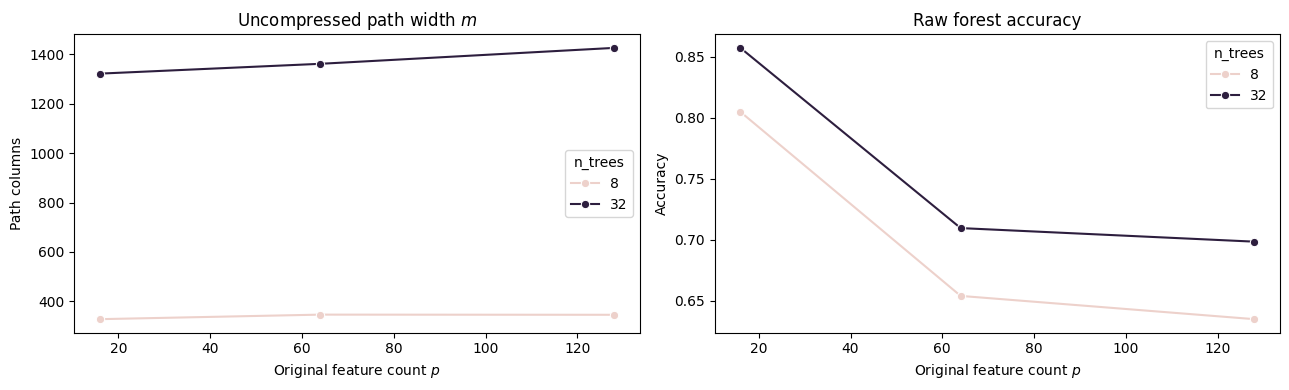

In [3]:
width_summary = (
    results.groupby(['n_features', 'n_trees'], as_index=False)
    .agg(path_width=('path_width', 'mean'), raw_accuracy=('raw_accuracy', 'mean'))
)
display(width_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=width_summary, x='n_features', y='path_width', hue='n_trees', marker='o', ax=axes[0])
axes[0].set_title('Uncompressed path width $m$')
axes[0].set_xlabel('Original feature count $p$')
axes[0].set_ylabel('Path columns')
sns.lineplot(data=width_summary, x='n_features', y='raw_accuracy', hue='n_trees', marker='o', ax=axes[1])
axes[1].set_title('Raw forest accuracy')
axes[1].set_xlabel('Original feature count $p$')
axes[1].set_ylabel('Accuracy')
fig.tight_layout()
plt.show()

## Accuracy as a function of projected dimension

The first view uses $d$ directly. The second and third use the scale-free ratios $d/p$ and $d/m$. A dotted line gives the paired raw-forest accuracy.

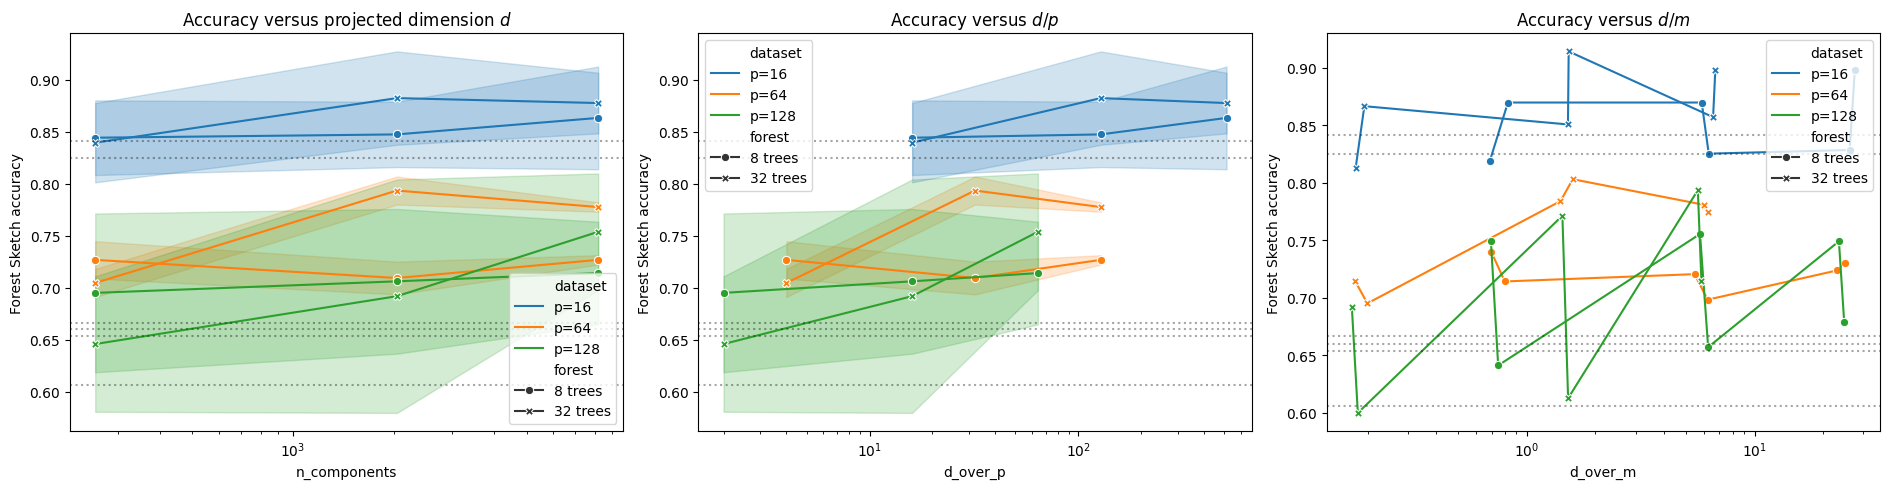

In [4]:
plot_data = results.copy()
plot_data['forest'] = plot_data['n_trees'].map(lambda value: f'{value} trees')
plot_data['dataset'] = plot_data['n_features'].map(lambda value: f'p={value}')
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for x_column, axis, title in [
    ('n_components', axes[0], 'Accuracy versus projected dimension $d$'),
    ('d_over_p', axes[1], 'Accuracy versus $d/p$'),
    ('d_over_m', axes[2], 'Accuracy versus $d/m$'),
]:
    sns.lineplot(
        data=plot_data, x=x_column, y='accuracy', hue='dataset', style='forest',
        markers=True, dashes=False, errorbar='sd', ax=axis,
    )
    axis.set_xscale('log')
    axis.set_title(title)
    axis.set_ylabel('Forest Sketch accuracy')
    for (n_features, n_trees), group in plot_data.groupby(['n_features', 'n_trees']):
        raw = group['raw_accuracy'].iloc[0]
        axis.axhline(raw, color='black', linestyle=':', alpha=0.35)
fig.tight_layout()
plt.show()

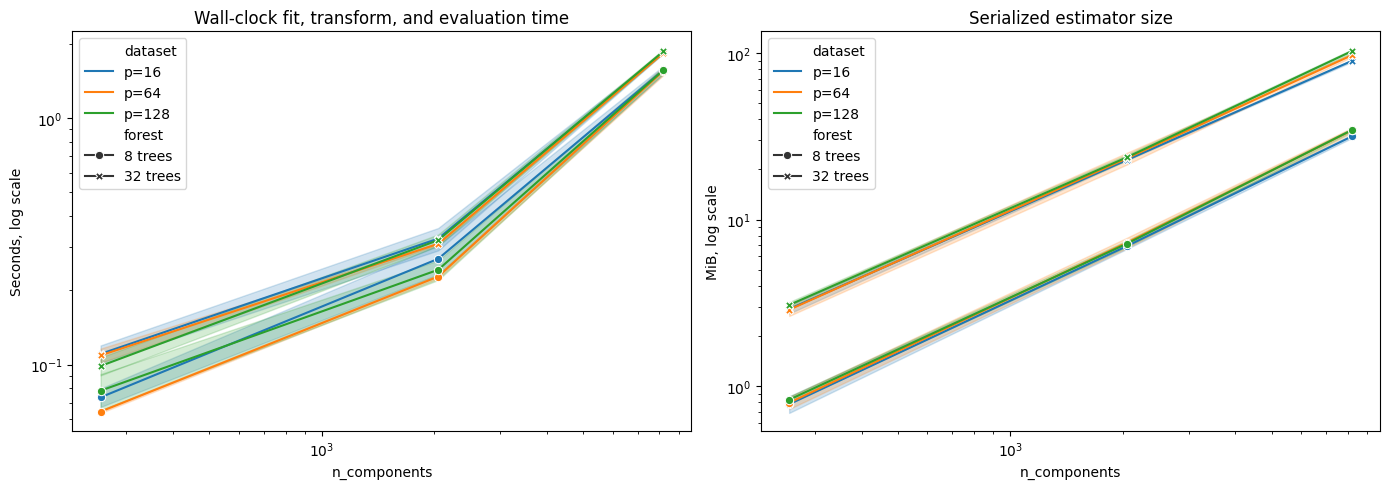

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=plot_data, x='n_components', y='wall_seconds', hue='dataset', style='forest', markers=True, dashes=False, errorbar='sd', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Wall-clock fit, transform, and evaluation time')
axes[0].set_ylabel('Seconds, log scale')
sns.lineplot(data=plot_data, x='n_components', y='serialized_model_mb', hue='dataset', style='forest', markers=True, dashes=False, errorbar='sd', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Serialized estimator size')
axes[1].set_ylabel('MiB, log scale')
fig.tight_layout()
plt.show()

## Paired critical-difference analysis for a representative slice

For one representative dataset/forest slice, dimensions are treated as competing methods and seeds are the blocks. This supplements, rather than replaces, the mean and standard-deviation summaries. The multi-factor curves above remain the primary view because a single pooled rank diagram would hide the factor structure.

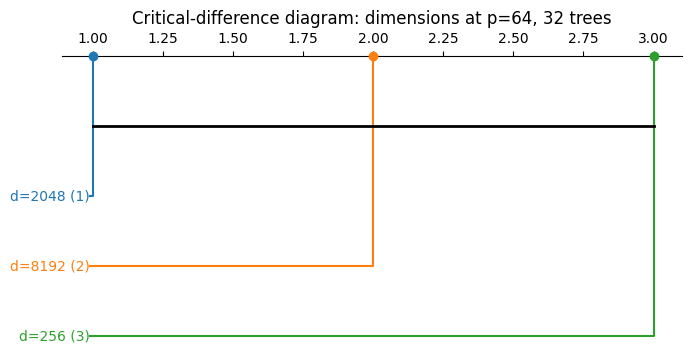

In [6]:
representative = results.query('n_features == 64 and n_trees == 32').copy()
representative['dimension'] = representative['n_components'].map(lambda value: f'd={value}')
plot_critical_difference(
    representative,
    block_column='seed',
    method_column='dimension',
    title='Critical-difference diagram: dimensions at p=64, 32 trees',
)
plt.show()

## Interpretation

The useful conclusion should be based on the curves and the paired results, not on one accuracy value. In particular, inspect whether the accuracy gap to the raw forest becomes small at a similar $d/p$ across datasets, at a similar $d/m$ across forest sizes, or only at a large absolute $d$. The path-width table makes clear how much uncompressed capacity is being replaced.

This notebook is an exploratory scaling study. It does not establish a universal rule for choosing $d$: the datasets are controlled synthetic variants, the forest depth is capped, and the projection implementation and machine affect the cost. The next step should be to repeat the promising ratio with larger and real datasets, while selecting $d$ only on training data.

In [7]:
summary = (
    results.groupby(['n_features', 'n_trees', 'n_components'], as_index=False)
    .agg(accuracy=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
         raw_accuracy=('raw_accuracy', 'mean'), path_width=('path_width', 'mean'),
         d_over_p=('d_over_p', 'mean'), d_over_m=('d_over_m', 'mean'),
         wall_seconds=('wall_seconds', 'mean'))
)
display(summary)
best = summary.loc[summary['accuracy'].idxmax()]
print(
    f"Best observed sketch accuracy: {best['accuracy']:.3f} at p={int(best['n_features'])}, "
    f"{int(best['n_trees'])} trees, d={int(best['n_components'])}; "
    f"mean d/p={best['d_over_p']:.1f}, mean d/m={best['d_over_m']:.2f}."
)

,n_features,n_trees,n_components,accuracy,accuracy_std,raw_accuracy,path_width,d_over_p,d_over_m,wall_seconds
0,16,8,256,0.844444,0.035917,0.804762,341.0,16.0,0.756989,0.073613
1,16,8,2048,0.847619,0.031427,0.804762,338.0,128.0,6.066819,0.268594
2,16,8,8192,0.863492,0.049385,0.804762,306.0,512.0,26.789552,1.566421
3,16,32,256,0.839683,0.038161,0.857143,1383.0,16.0,0.185466,0.110455
4,16,32,2048,0.882540,0.044896,0.857143,1347.0,128.0,1.520437,0.324233
5,16,32,8192,0.877778,0.029182,0.857143,1234.0,512.0,6.639428,1.845494
6,64,8,256,0.726984,0.017958,0.653968,343.0,4.0,0.749727,0.064425
7,64,8,2048,0.709524,0.015713,0.653968,353.0,32.0,5.826435,0.227518
8,64,8,8192,0.726984,0.004490,0.653968,344.0,128.0,23.853462,1.553169
9,64,32,256,0.704762,0.013469,0.709524,1365.0,4.0,0.188242,0.108902


Best observed sketch accuracy: 0.883 at p=16, 32 trees, d=2048; mean d/p=128.0, mean d/m=1.52.
